Upload 3 gambar:
1. Underexposed
2. Overexposed
3. Iluminasi tidak merata


Saving overexposed.jpg to overexposed (6).jpg
Saving iluminasi-tdk-merata.jpg to iluminasi-tdk-merata (6).jpg
Saving underexposed.jpg to underexposed (6).jpg

IMAGE: Underexposed


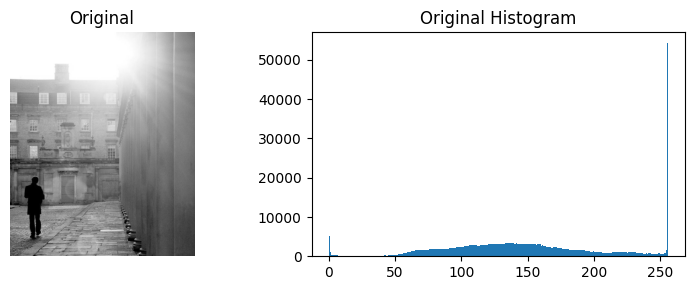

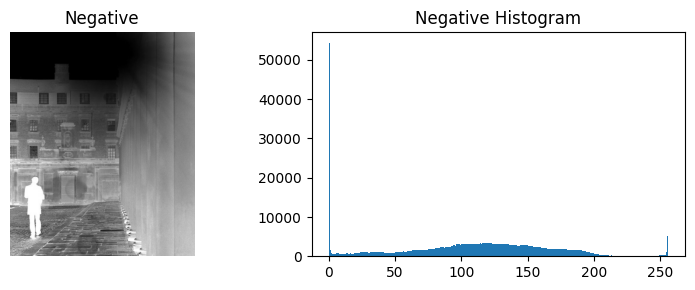

Negative
Contrast Ratio  : 255
Entropy         : 7.22387689168309
SNR             : -0.8119772203208991
------------------------------


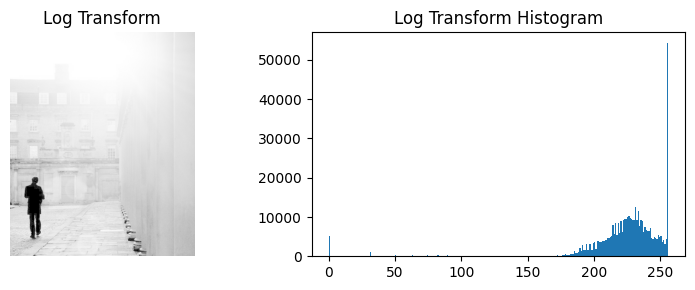

Log Transform
Contrast Ratio  : 255
Entropy         : 5.897862194565633
SNR             : 0.17947529077097374
------------------------------


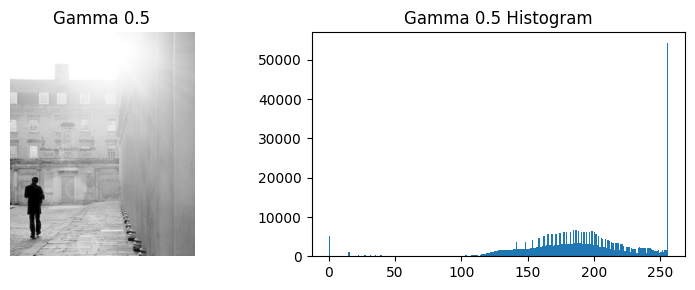

Gamma 0.5
Contrast Ratio  : 255
Entropy         : 6.7202054185079785
SNR             : -0.45238484175853433
------------------------------


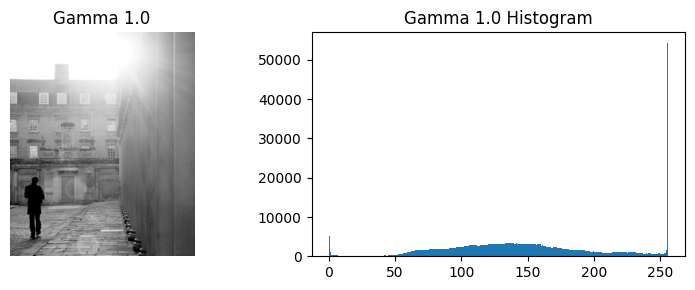

Gamma 1.0
Contrast Ratio  : 255
Entropy         : 7.22387689168309
SNR             : 0
------------------------------


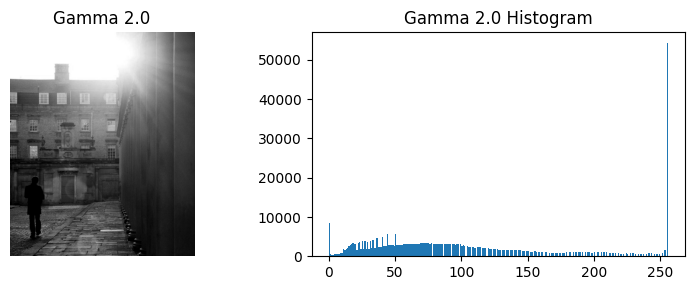

Gamma 2.0
Contrast Ratio  : 255
Entropy         : 6.993984217524657
SNR             : 0.8936444266382909
------------------------------


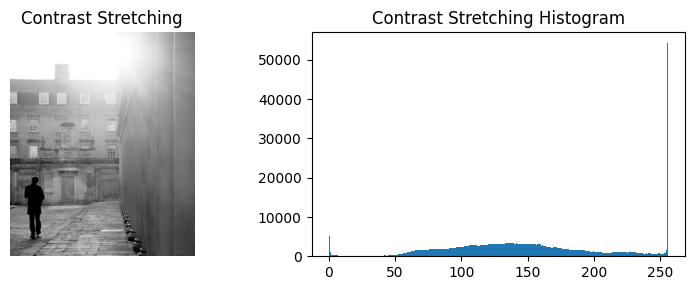

Contrast Stretching
Contrast Ratio  : 255
Entropy         : 7.22387689168309
SNR             : 0
------------------------------


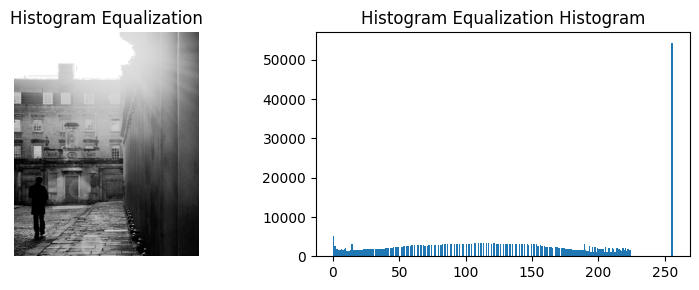

Histogram Equalization
Contrast Ratio  : 255
Entropy         : 7.0164468414331145
SNR             : -0.14359762898208414
------------------------------


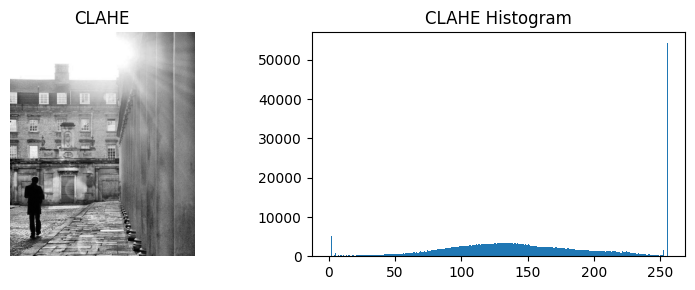

CLAHE
Contrast Ratio  : 255
Entropy         : 7.241728232026148
SNR             : 0.31352657873607903
------------------------------

IMAGE: Overexposed


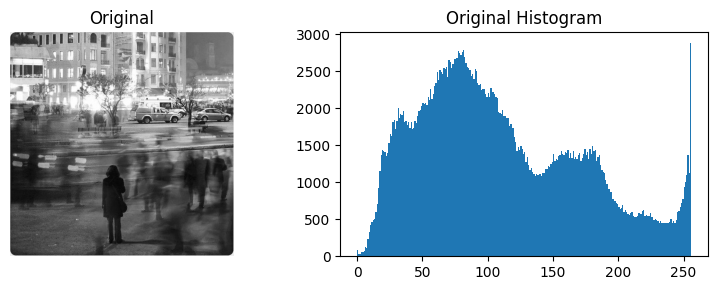

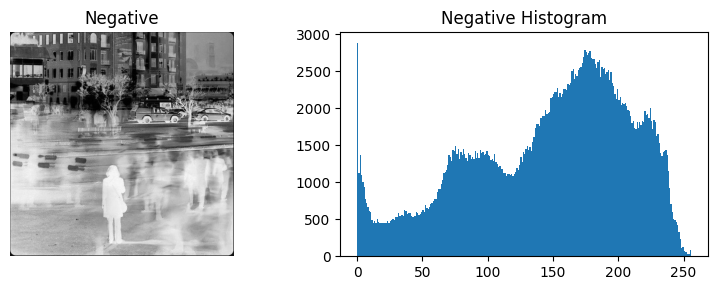

Negative
Contrast Ratio  : 255
Entropy         : 7.7895497662001985
SNR             : -0.6326834576797337
------------------------------


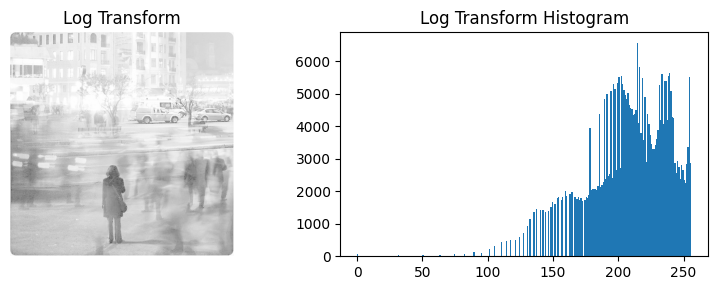

Log Transform
Contrast Ratio  : 255
Entropy         : 6.680946231843484
SNR             : 1.8513631022494281
------------------------------


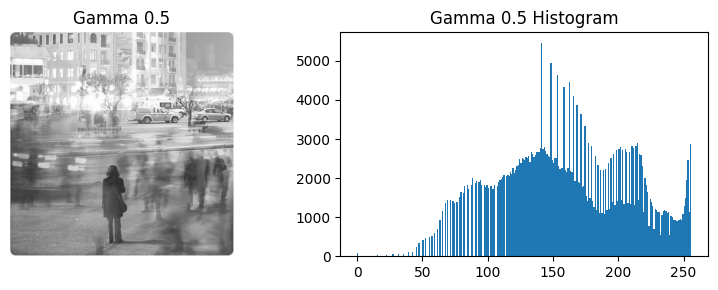

Gamma 0.5
Contrast Ratio  : 255
Entropy         : 7.40249405205601
SNR             : 0.16775549710417959
------------------------------


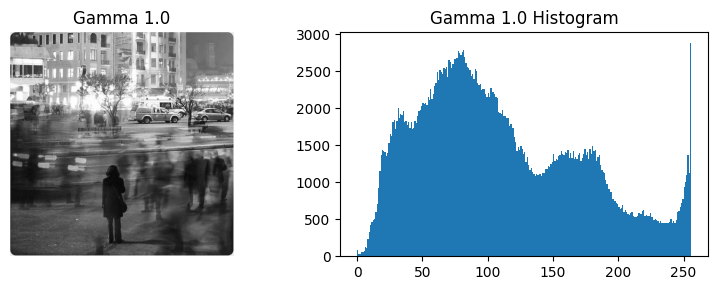

Gamma 1.0
Contrast Ratio  : 255
Entropy         : 7.7895497662001985
SNR             : 0
------------------------------


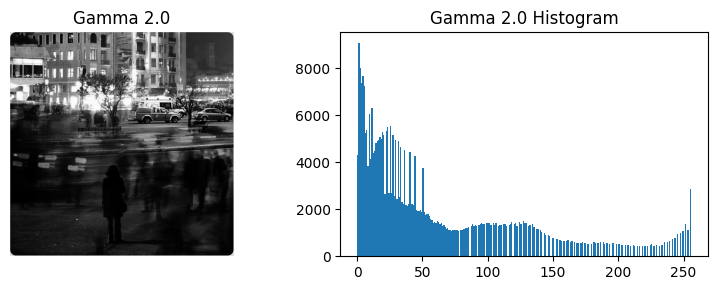

Gamma 2.0
Contrast Ratio  : 255
Entropy         : 7.108969978611986
SNR             : 0.27422239552800426
------------------------------


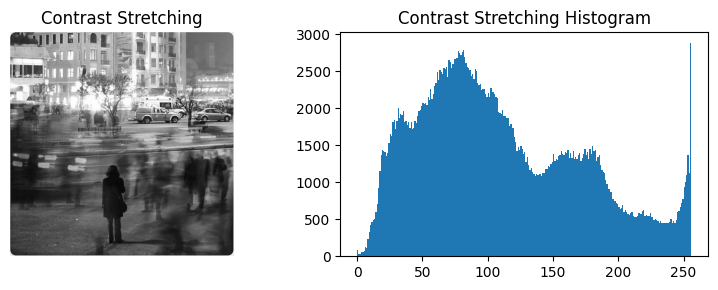

Contrast Stretching
Contrast Ratio  : 255
Entropy         : 7.7895497662001985
SNR             : 0
------------------------------


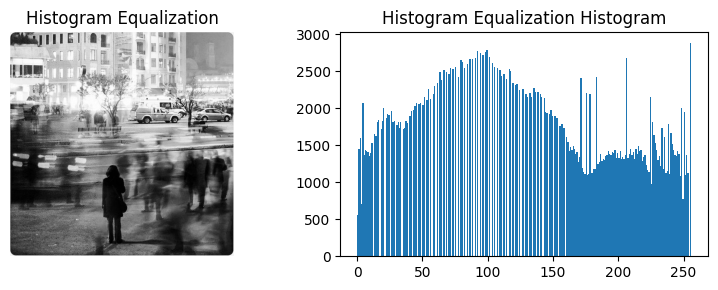

Histogram Equalization
Contrast Ratio  : 255
Entropy         : 7.599859691485664
SNR             : 0.7196602674074503
------------------------------


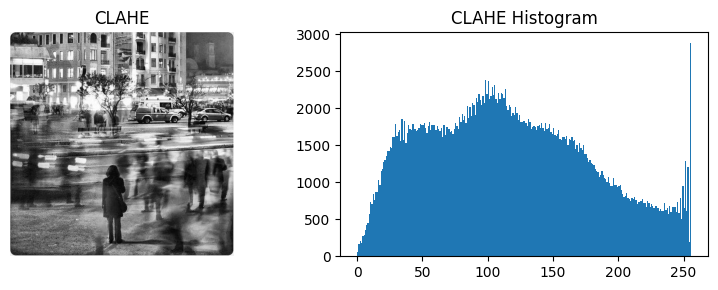

CLAHE
Contrast Ratio  : 255
Entropy         : 7.875780992260034
SNR             : 0.5162446225143295
------------------------------

IMAGE: Uneven Illumination


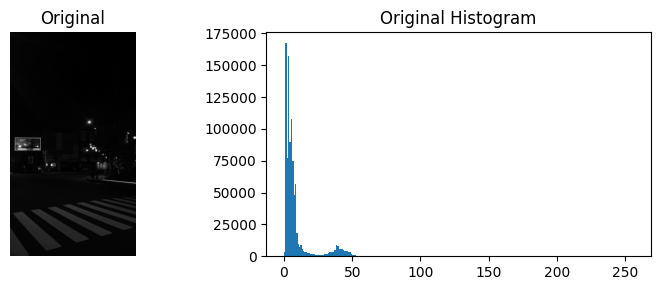

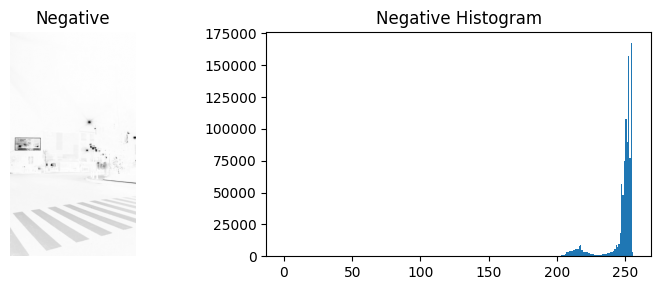

Negative
Contrast Ratio  : 255
Entropy         : 4.098693612681863
SNR             : -3.4061557757948724
------------------------------


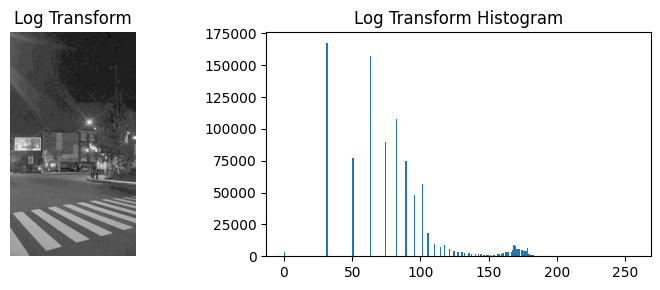

Log Transform
Contrast Ratio  : 255
Entropy         : 4.076624470740078
SNR             : -2.744730940874203
------------------------------


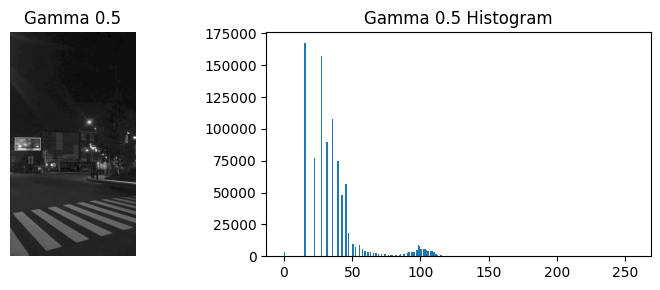

Gamma 0.5
Contrast Ratio  : 255
Entropy         : 4.09371987715191
SNR             : -5.272470808130429
------------------------------


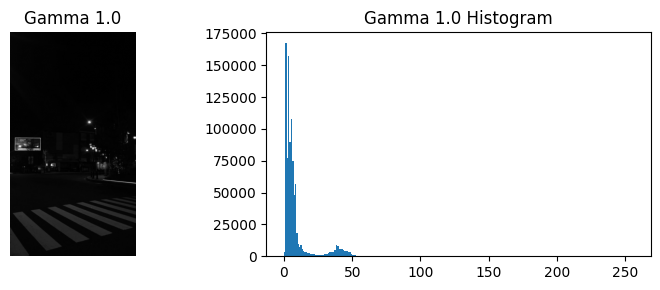

Gamma 1.0
Contrast Ratio  : 255
Entropy         : 4.098693612681863
SNR             : 0
------------------------------


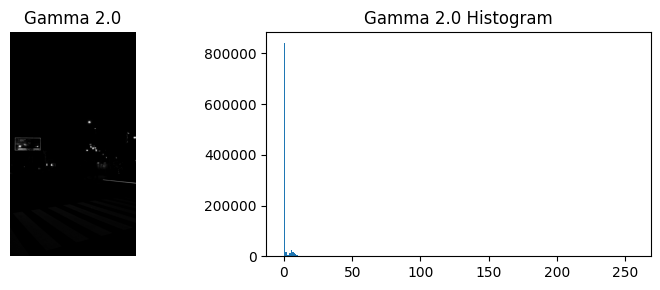

Gamma 2.0
Contrast Ratio  : 255
Entropy         : 1.045136501925778
SNR             : 0.12391827146764978
------------------------------


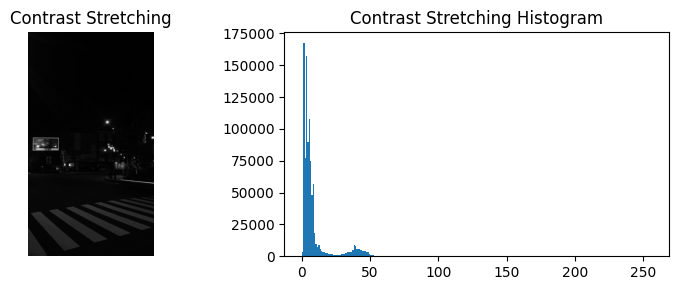

Contrast Stretching
Contrast Ratio  : 255
Entropy         : 4.098693612681863
SNR             : 0
------------------------------


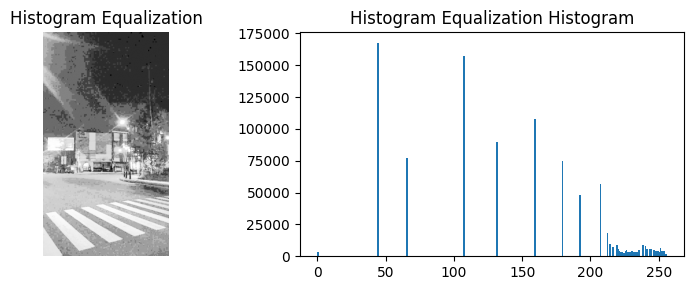

Histogram Equalization
Contrast Ratio  : 255
Entropy         : 3.9852816314038346
SNR             : -4.672377501960604
------------------------------


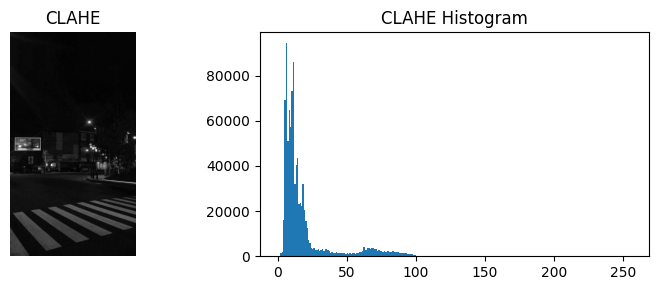

CLAHE
Contrast Ratio  : 254
Entropy         : 5.137463791337513
SNR             : -2.2402506618662645
------------------------------


In [1]:
# ============================
# PIPELINE ENHANCEMENT CITRA
# ============================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.measure import shannon_entropy

# ===============
# UPLOAD GAMBAR
# ===============

print("Upload 3 gambar:")
print("1. Underexposed")
print("2. Overexposed")
print("3. Iluminasi tidak merata")

uploaded = files.upload()

# ambil nama file
filenames = list(uploaded.keys())

under = cv2.imread(filenames[0],0)
over = cv2.imread(filenames[1],0)
uneven = cv2.imread(filenames[2],0)

images = {
    "Underexposed": under,
    "Overexposed": over,
    "Uneven Illumination": uneven
}

# ==================
# FUNGSI HISTOGRAM
# ==================

def show_histogram(img, title):
    plt.figure()
    plt.title(title)
    plt.hist(img.ravel(),256,[0,256])
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.show()

# ========
# METRIK
# ========

def contrast_ratio(img):
    return img.max() - img.min()

def entropy(img):
    return shannon_entropy(img)

def snr(original, enhanced):
    noise = original - enhanced
    signal = np.mean(original**2)
    noise_power = np.mean(noise**2)
    if noise_power == 0:
        return 0
    return 10*np.log10(signal/noise_power)

# ==================
# POINT PROCESSING
# ==================

def negative(img):
    return 255-img

def log_transform(img):
    img = img.astype(np.float32)
    c = 255 / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img)
    log_img = np.clip(log_img,0,255)
    return log_img.astype(np.uint8)

def gamma_correction(img,gamma):
    img_norm = img/255.0
    gamma_img = np.power(img_norm,gamma)
    return np.uint8(gamma_img*255)

# =======================
# HISTOGRAM ENHANCEMENT
# =======================

def contrast_stretch(img):
    min_val = np.min(img)
    max_val = np.max(img)
    stretched = (img-min_val)/(max_val-min_val)*255
    return np.uint8(stretched)

def hist_equal(img):
    return cv2.equalizeHist(img)

def clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
    return clahe.apply(img)

def show_result(img, title):

    plt.figure(figsize=(8,3))

    # gambar
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')

    # histogram
    plt.subplot(1,2,2)
    plt.hist(img.ravel(), bins=256, range=(0,256))
    plt.title(title + " Histogram")

    plt.tight_layout()
    plt.show()

# ==========
# PIPELINE
# ==========

for name,img in images.items():

    print("\n==============================")
    print("IMAGE:",name)
    print("==============================")

    # tampilkan original
    show_result(img, "Original")

    # POINT PROCESSING
    neg = negative(img)
    log_img = log_transform(img)

    gamma05 = gamma_correction(img,0.5)
    gamma1 = gamma_correction(img,1)
    gamma2 = gamma_correction(img,2)

    # HISTOGRAM BASED
    stretch = contrast_stretch(img)
    equal = hist_equal(img)
    clahe_img = clahe(img)

    results = {
        "Negative":neg,
        "Log Transform":log_img,
        "Gamma 0.5":gamma05,
        "Gamma 1.0":gamma1,
        "Gamma 2.0":gamma2,
        "Contrast Stretching":stretch,
        "Histogram Equalization":equal,
        "CLAHE":clahe_img
    }

    for method,res in results.items():

        show_result(res, method)

        print(method)
        print(f"{'Contrast Ratio':15} : {contrast_ratio(res)}")
        print(f"{'Entropy':15} : {entropy(res)}")
        print(f"{'SNR':15} : {snr(img,res)}")
        print("-"*30)